In [1]:
import requests
import pandas as pd
from tqdm import tqdm
import tmdbdata as td
import numpy as np

In [2]:
#importer les ids et les infos des films de tmdb en format csv

#ids= td.get_movie_ids_list_map(500, headers=td.headers)
#df=td.get_movies_info(ids,headers=td.headers)
#df.to_csv("data_tmdb_map.csv", sep=',', index=False, encoding='utf-8')


In [3]:
#lire la base de données 
df=pd.read_csv("data_tmdb_map.csv",sep=',')
df_tmdb=td.clean_data(df)

#convertir en minuscule la colonne original_title 
df_tmdb['original_title']=df_tmdb['original_title'].str.lower()
df_tmdb.tail(3)

,budget,id,original_title,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,main_genre_id,main_genre_name,full_poster_path,overview_count,title_count,timestamp
9995,0,759430,blossom,"Engaged to the Nightingale, Rose will be ready...",0.655,2020-10-31,0,7,Blossom,4.0,1,27,Horror,https://image.tmdb.org/t/p/original//sD0XYqGkg...,93,7,1604102400
9996,0,692239,je parle à mes démons,Patrice is an inmate in the french prison Bois...,0.440,2020-10-31,0,24,I Speak To My Demons,0.0,0,99,Documentary,https://image.tmdb.org/t/p/original//vh02q3sJf...,185,20,1604102400
9998,0,1137853,revenge,"In love, a girl goes to join her ex-boyfriend ...",0.014,2020-11-01,0,14,Revenge,0.0,0,18,Drama,NaN,180,7,1604188800


In [4]:
#importer la base de données des lieux de tournage parisiens

#ids= td.get_movie_ids_list_map(500, headers=td.headers)
#df=td.get_movies_info(ids,headers=td.headers)
#df.to_csv("data_tmdb_map.csv", sep=',', index=False, encoding='utf-8')

#lire la base de données 
df_lieux=pd.read_csv("lieux-de-tournage-a-paris.csv",sep=';')

#filtrer la base de données pour ne retenir que les fomats en commun avec tmdb
df_lieux=df_lieux[df_lieux['Type de tournage'].isin(['Long métrage', 'Téléfilm'])]
print("Il y a " + str(df_lieux.shape[0]) + " films dans la base de données des lieux de tournage parisiens")
df_lieux.head(3)



Il y a 7897 films dans la base de données des lieux de tournage parisiens


,Identifiant du lieu,Année du tournage,Type de tournage,Titre,Réalisateur,Producteur,Localisation de la scène,Code postal,Date de début,Date de fin,Coordonnée en X,Coordonnée en Y,geo_shape,geo_point_2d
3,2019-535,2019,Long métrage,En attendant qui ? Mai,Marc RECUENCO,SerialBstudio,"rue léon droux, 75017 paris",75017.0,2019-06-10,2019-06-10,2.318919,48.882377,"{""coordinates"": [2.318919045887731, 48.8823773...","48.882377323745416, 2.318919045887731"
9,2019-1525,2019,Long métrage,Les Années 10 - L'infiltré,Thierry De Peretti,Les Films Velvet,"87 avenue de la grande armée, 75116 paris",75116.0,2019-11-07,2019-11-09,2.284072,48.876903,"{""coordinates"": [2.284072411245358, 48.8769031...","48.8769031427761, 2.284072411245358"
11,2018-912,2018,Long métrage,It Must Be Heaven,Elia Suleiman,Rectangle Productions,"passage de la canopée, 75001 paris",75001.0,2018-08-12,2018-08-12,2.346423,48.862158,"{""coordinates"": [2.346422664713688, 48.8621582...","48.86215827046971, 2.346422664713688"


In [5]:
#merge les deux bases de données sur le titre du film
df_lieux_renomme = df_lieux.rename(columns={'Titre': 'original_title'})
df_lieux_renomme['original_title'] = df_lieux_renomme['original_title'].str.lower()
df_merge = pd.merge(df_tmdb, df_lieux_renomme, how='inner', on='original_title')
df_merge.head(3)

,budget,id,original_title,overview,popularity,release_date,revenue,runtime,title,vote_average,...,Réalisateur,Producteur,Localisation de la scène,Code postal,Date de début,Date de fin,Coordonnée en X,Coordonnée en Y,geo_shape,geo_point_2d
0,0,504167,nadia,"Nadia raised, alone, her son Noé in Paris subu...",1.026,2016-02-10,0,89,Nadia,5.3,...,LEA MAZER,MURMURES PRODUCTIONS,49/49BIS BOULEVARD DE PICPUS,75012.0,2016-04-21,2016-04-21,2.401806,48.844582,"{""coordinates"": [2.401805999975272, 48.8445819...","48.84458199957575, 2.401805999975272"
1,0,504167,nadia,"Nadia raised, alone, her son Noé in Paris subu...",1.026,2016-02-10,0,89,Nadia,5.3,...,LEA MAZER,MURMURES PRODUCTIONS,146 RUE DU FAUBOURG POISSONNIERE,75009.0,2016-04-15,2016-04-15,2.349026,48.877580,"{""coordinates"": [2.349025999974713, 48.8775800...","48.87758000021916, 2.349025999974713"
2,0,504167,nadia,"Nadia raised, alone, her son Noé in Paris subu...",1.026,2016-02-10,0,89,Nadia,5.3,...,LEA MAZER,MURMURES PRODUCTIONS,67 BOULEVARD PICPUS,75012.0,2016-05-03,2016-05-03,2.399661,48.846623,"{""coordinates"": [2.3996610002713763, 48.846623...","48.84662300018563, 2.3996610002713763"


In [6]:
#afficher les films en commun entre les deux bases de données
films_communs=df_merge["original_title"].unique()
print("Il y a " + str(len(films_communs)) + " films en commun dans les deux bases de données")
films_communs

Il y a 179 films en commun dans les deux bases de données


array(['nadia', 'barbara', 'goliath', 'maman a tort',
       "vous n'aurez pas ma haine", 'la fille de brest', 'eva', 'dalida',
       "l'ascension", 'raid dingue', 'seuls', 'alibi.com',
       "l'embarras du choix", 'gangsterdam', 'la consolation',
       'corporate', 'bienvenue au gondwana', 'jour j',
       'je voulais juste rentrer chez moi', 'blockbuster',
       "l'amant d'un jour", 'les ex', 'bad buzz', 'le redoutable',
       'cherchez la femme', 'mon poussin', 'little jaffna', 'burn out',
       'une vie violente', 'lola pater', 'la douleur',
       '120 battements par minute', 'rodin', 'voir le jour',
       "l'un dans l'autre", 'les affamés', 'le petit spirou', 'coexister',
       'knock', 'jeune femme', 'carbone', "d'après une histoire vraie",
       'jalouse', 'maryline', 'simon et théodore', 'le brio', 'plonger',
       "c'est tout pour moi", 'la sainte famille', 'arthur rambo',
       'que le diable nous emporte', 'la bête', 'une saison en france',
       'les tuche 3', 

In [7]:
#package nécessaire 
import geopandas as gpd
from shapely.geometry import Point

#créer la colonne geometry avec des objets Point
geometry = [Point(xy) for xy in zip(df_merge["Coordonnée en X"], df_merge["Coordonnée en Y"])]

#convertir en GeoDataFrame
gdf_merge = gpd.GeoDataFrame(df_merge, geometry=geometry)

#définir le système de projection
gdf_merge.set_crs(epsg=4326, inplace=True)  # (système global utilisé pour les coordonnées GPS)

print(gdf_merge.head(3))

   budget      id original_title  \
0       0  504167          nadia   
1       0  504167          nadia   
2       0  504167          nadia   

                                            overview  popularity release_date  \
0  Nadia raised, alone, her son Noé in Paris subu...       1.026   2016-02-10   
1  Nadia raised, alone, her son Noé in Paris subu...       1.026   2016-02-10   
2  Nadia raised, alone, her son Noé in Paris subu...       1.026   2016-02-10   

   revenue  runtime  title  vote_average  ...            Producteur  \
0        0       89  Nadia           5.3  ...  MURMURES PRODUCTIONS   
1        0       89  Nadia           5.3  ...  MURMURES PRODUCTIONS   
2        0       89  Nadia           5.3  ...  MURMURES PRODUCTIONS   

             Localisation de la scène Code postal Date de début  Date de fin  \
0      49/49BIS  BOULEVARD  DE PICPUS     75012.0    2016-04-21   2016-04-21   
1  146  RUE  DU FAUBOURG POISSONNIERE     75009.0    2016-04-15   2016-04-15   
2    

In [8]:
#nettoyage de la base de données mergée

#filtrage des lignes selon leur geometry : longitude et latitude de Paris X: 2.33333 Y: 48.866669
#filtrage des lignes selon le code postal : le département de Paris est le 75
filtred_gdf_merge=gdf_merge[(gdf_merge['Coordonnée en X']>2) & (gdf_merge['Coordonnée en X']<3) & (gdf_merge['Coordonnée en Y']>48) & (gdf_merge['Coordonnée en Y']<49) & (gdf_merge['Code postal'].astype(str).str[:2] == '75')]
filtred_gdf_merge.geometry.describe()

count                               1942
unique                              1490
top       POINT (2.33872114 48.88585596)
freq                                  14
Name: geometry, dtype: object

In [9]:
#renommer l'index 75116 par 75016
filtred_gdf_merge['Code postal'] = filtred_gdf_merge['Code postal'].replace(75116.0, 75016.0)
print(filtred_gdf_merge['Code postal'].unique())


[75012. 75009. 75016. 75005. 75011. 75017. 75001. 75018. 75004. 75006.
 75020. 75007. 75013. 75002. 75008. 75014. 75015. 75019. 75010. 75003.]


/opt/conda/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


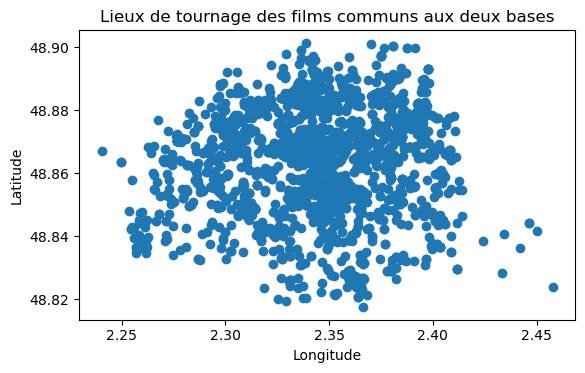

In [10]:
#visualiser les données sur une carte
import matplotlib.pyplot as plt
filtred_gdf_merge.plot()
plt.title('Lieux de tournage des films communs aux deux bases')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Le but de cette première partie est d'améliorer ce graphique pour mieux comprendre la répartition spatiale des lieux de tournage parisiens communs aux deux bases de données. 

In [11]:
#compter le nombre d'observations par arrondissement
s_count = filtred_gdf_merge.groupby('Code postal').size()
df_count = s_count.to_frame()
print(df_count)


               0
Code postal     
75001.0       84
75002.0       72
75003.0       29
75004.0      127
75005.0       91
75006.0       57
75007.0      104
75008.0      122
75009.0      119
75010.0       96
75011.0      107
75012.0       99
75013.0       87
75014.0       47
75015.0       78
75016.0      144
75017.0       60
75018.0      162
75019.0      155
75020.0      102


In [12]:
#groupement par 'code postal' et calcul de la moyenne des coordonnées GPS
mean_x = filtred_gdf_merge.groupby('Code postal')['Coordonnée en X'].mean()
mean_y = filtred_gdf_merge.groupby('Code postal')['Coordonnée en Y'].mean()
df_mean_x = mean_x.to_frame()
df_mean_y = mean_y.to_frame()

print(df_mean_x)



             Coordonnée en X
Code postal                 
75001.0             2.338428
75002.0             2.343292
75003.0             2.358427
75004.0             2.355304
75005.0             2.349963
75006.0             2.334682
75007.0             2.311483
75008.0             2.310610
75009.0             2.338814
75010.0             2.359721
75011.0             2.377676
75012.0             2.396606
75013.0             2.363626
75014.0             2.329946
75015.0             2.299602
75016.0             2.275745
75017.0             2.308029
75018.0             2.342811
75019.0             2.385763
75020.0             2.396771


In [13]:
#ajouter des colonnes à df_mean_x afin d'améliorer la représentation cartographique

df_mean_x['Coordonnée en Y']=df_mean_y['Coordonnée en Y']
df_mean_x['Effectif']=df_count[0]

#Fréquences des lieux de tournage par arrondissement
effectif_total=df_mean_x['Effectif'].sum()
df_mean_x['Fréquence']=df_mean_x['Effectif']/effectif_total

#Rayons de cercles dont l'aire est proportionnelle à la fréquence par arrondisssement
alpha=0.003 #échelle
df_mean_x['Rayon']=np.sqrt((alpha*df_mean_x['Fréquence'])/np.pi)

print(df_mean_x)

             Coordonnée en X  Coordonnée en Y  Effectif  Fréquence     Rayon
Code postal                                                                 
75001.0             2.338428        48.862168        84   0.043254  0.006427
75002.0             2.343292        48.868115        72   0.037075  0.005950
75003.0             2.358427        48.864625        29   0.014933  0.003776
75004.0             2.355304        48.854490       127   0.065396  0.007902
75005.0             2.349963        48.846230        91   0.046859  0.006689
75006.0             2.334682        48.850862        57   0.029351  0.005294
75007.0             2.311483        48.854318       104   0.053553  0.007151
75008.0             2.310610        48.873552       122   0.062822  0.007745
75009.0             2.338814        48.877655       119   0.061277  0.007650
75010.0             2.359721        48.875103        96   0.049434  0.006871
75011.0             2.377676        48.860710       107   0.055098  0.007254

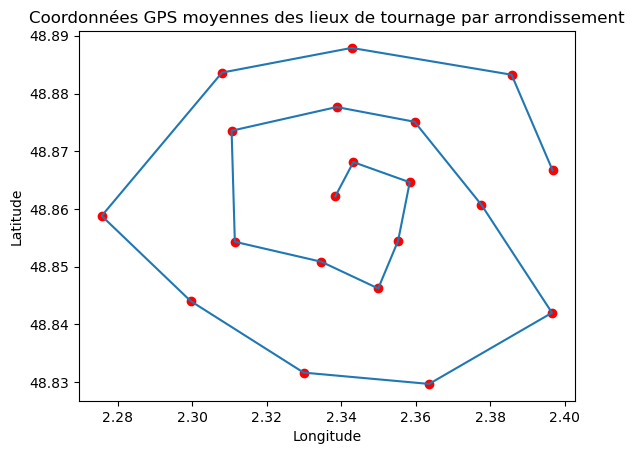

In [14]:
#visualiser les données sur une carte
plt.plot(df_mean_x['Coordonnée en X'],df_mean_y['Coordonnée en Y'])
plt.scatter(df_mean_x['Coordonnée en X'],df_mean_y['Coordonnée en Y'], color='red')
plt.title('Coordonnées GPS moyennes des lieux de tournage par arrondissement')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

En prenant la moyenne des coordonnées GPS par arrondissement, on retrouve bien l'emplacement approximatif de chaque arrondissement et la disposition "en escargot".

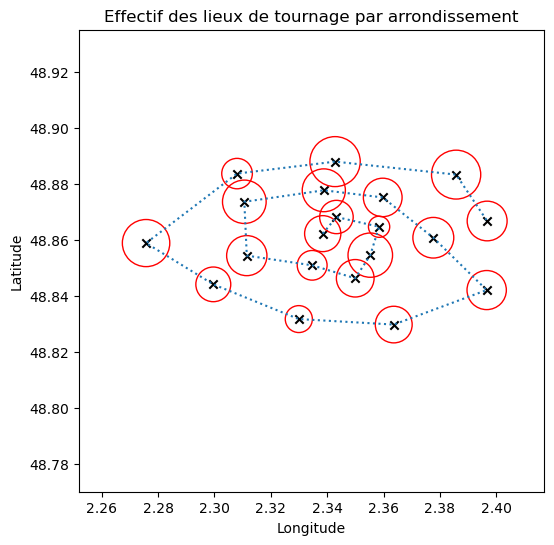

In [15]:
# Créer une figure et un axe
#fig, ax = plt.subplots()

# Ajouter un cercle
#circle = plt.Circle((0.5, 0.5), 0.3, color='red', fill=True)  # Cercle rempli
#ax.add_artist(circle)

# Ajuster les limites de l'axe
#ax.set_xlim(0, 1)
#ax.set_ylim(0, 1)
#ax.set_aspect('equal')



fig, ax = plt.subplots(figsize=(6, 6)) #format de la feuille carré de coté 6 pouces
ax.set_xlim(2.252, 2.417)
ax.set_ylim(48.77, 48.935)

#afficher les coordonnées moyennes des lieux de tournage par arrondissement
plt.scatter(df_mean_x['Coordonnée en X'],df_mean_y['Coordonnée en Y'], marker='x', color='k')

#les relier
plt.plot(df_mean_x['Coordonnée en X'],df_mean_y['Coordonnée en Y'], linestyle='dotted')


#afficher des cercles dont le rayon correspond à l'effectif par arrondissement
for code_postal in filtred_gdf_merge['Code postal'].unique():
    circle= plt.Circle((df_mean_x['Coordonnée en X'].loc[code_postal], 
    df_mean_x['Coordonnée en Y'].loc[code_postal]), 
    df_mean_x['Rayon'].loc[code_postal], 
    color='red', fill=False)  # Cercle rempli
    ax.add_artist(circle)

plt.title('Effectif des lieux de tournage par arrondissement')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [16]:
#packages necessaires
!pip install pandas fiona shapely pyproj rtree 
!pip install contextily
!pip install geopandas
!pip install topojson

# # Cartiflette:
!pip install py7zr geopandas openpyxl tqdm s3fs
!pip install PyYAML xlrd
!pip install git+https://github.com/inseefrlab/cartiflette


!pip install --upgrade urllib3
!pip install --upgrade cartiflette
import contextily as ctx
import matplotlib.pyplot as plt
from cartiflette import carti_download

  Cloning https://github.com/inseefrlab/cartiflette to /tmp/pip-req-build-vaqete9m
  Running command git clone --filter=blob:none --quiet https://github.com/inseefrlab/cartiflette /tmp/pip-req-build-vaqete9m
  Resolved https://github.com/inseefrlab/cartiflette to commit f6b0c5d049bd6dcae7b437bd931957371da24278
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached urllib3-1.26.20-py2.py3-none-any.whl.metadata (50 kB)
Using cached urllib3-1.26.20-py2.py3-none-any.whl (144 kB)
  Created wheel for cartiflette: filename=cartiflette-0.0.2-py3-none-any.whl size=56573 sha256=7e59f26a71f86d2e94fde43e66cedc1ab47120e738ca086278e0ae3cc7c1d1e0
  Stored in directory: /tmp/pip-ephem-wheel-cache-fy_0rhwe/wheels/e2/79/c0/4a3a02595ceab7ab6d4916e63b3f8a6f3d7d45aa209631f6f8
Successfully built cartiflette
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.3.0
    Uninstalling urllib3-2.3.

In [17]:
#importer les données des bordures des arrondissements
from cartiflette import carti_download

arrondissement_borders = carti_download(
    crs=4326,
    values=["75"],
    borders="COMMUNE_ARRONDISSEMENT",
    vectorfile_format="geojson",
    filter_by="DEPARTEMENT",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022,
)

print(arrondissement_borders.head(3))

  INSEE_DEP  INSEE_REG                        ID                      NOM  \
0        75         11  ARR_MUNI0000000009736045  Paris 3e Arrondissement   
1        75         11  ARR_MUNI0000000009736046  Paris 2e Arrondissement   
2        75         11  ARR_MUNI0000000009736545  Paris 4e Arrondissement   

  INSEE_COM                    STATUT  POPULATION INSEE_COG  ARR    CV  ...  \
0     75056  Arrondissement municipal       34025     75103  751  75ZZ  ...   
1     75056  Arrondissement municipal       21595     75102  751  75ZZ  ...   
2     75056  Arrondissement municipal       29131     75104  751  75ZZ  ...   

  AAV2020 TAAV2017  TDAAV2017 CATEAAV2020  BV2012  LIBELLE_DEPARTEMENT  \
0     001        5         50          11   75056                Paris   
1     001        5         50          11   75056                Paris   
2     001        5         50          11   75056                Paris   

  LIBELLE_REGION    PAYS                            SOURCE  \
0  Île-de-Franc

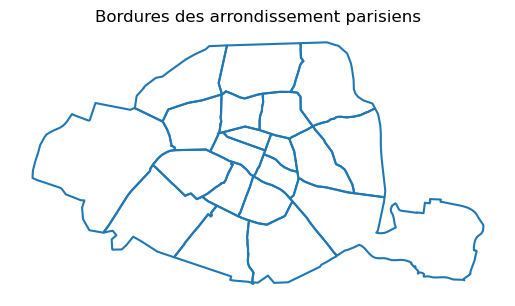

In [18]:
#afficher les bordures des arrondissements
base = arrondissement_borders.boundary.plot()


plt.plot(ax=base)
base.set_title('Bordures des arrondissement parisiens')
base.set_axis_off()

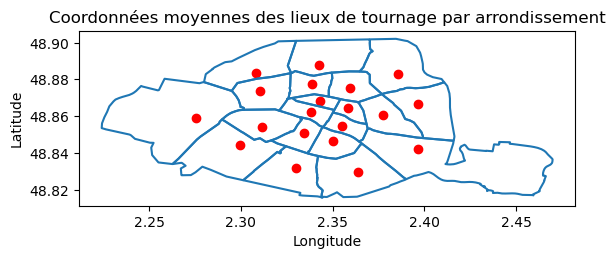

In [ ]:
#afficher les données sur les lieux de tournage parisiens avec le fond de carte

df_coord=df_mean_x.loc[:, ['Coordonnée en X','Coordonnée en Y']]

#conversion en geodataframe

#créer la colonne geometry avec des objets Point
geometry = [Point(xy) for xy in zip(df_coord["Coordonnée en X"], df_coord["Coordonnée en Y"])]

#convertir en GeoDataFrame
gdf_coord = gpd.GeoDataFrame(df_coord, geometry=geometry)

#définir le système de projection
gdf_coord.set_crs(epsg=2154, inplace=True)

#afficher le fond de carte
base = arrondissement_borders.boundary.plot()

#afficher les coordonnées moyennes des lieux de tournage par arrondissement
gdf_coord.plot(ax=base,color='red')

plt.title('Coordonnées moyennes des lieux de tournage par arrondissement')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


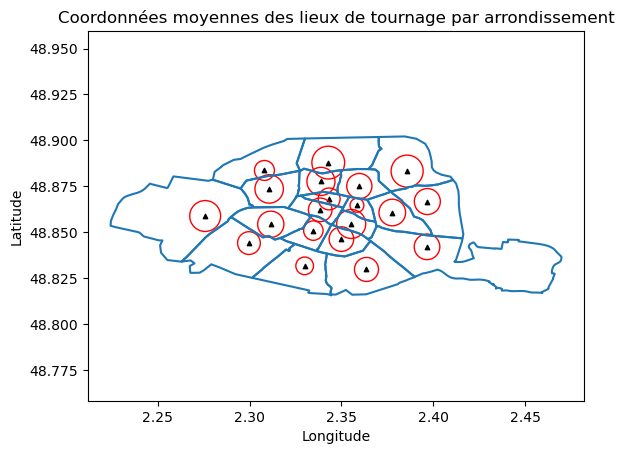

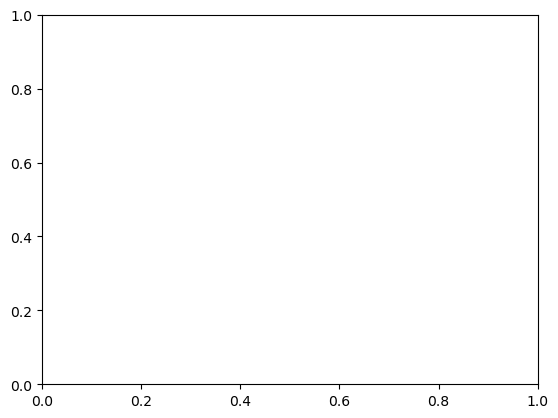

In [ ]:
base = arrondissement_borders.boundary.plot()

#créer un graphique
fig, ax = plt.subplots()
ax=base
ax.axis('equal')

#afficher les coordonnées moyennes des lieux de tournage par arrondissement
gdf_coord.plot(ax=base,color='k',marker='^',markersize=10)

#afficher des cercles dont le rayon correspond à l'effectif par arrondissement
for code_postal in filtred_gdf_merge['Code postal'].unique():
    circle= plt.Circle((df_mean_x['Coordonnée en X'].loc[code_postal], 
    df_mean_x['Coordonnée en Y'].loc[code_postal]), 
    df_mean_x['Rayon'].loc[code_postal], 
    color='red', fill=False) 
    ax.add_artist(circle)
ax.set_title('Coordonnées moyennes et effectifs des lieux de tournage par arrondissement')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

Les lieux de tournage sont globalement répartis sur l'ensemble du territoire de chaque arrondissement, les triangles noirs se situant en général au milieu de chaque arrondissement. On relève néanmoins quelques exceptions comme autour de la butte Montmartre. En effet, elle se situe entre le 10 et le 18ème arrondissement et on remarque que les triangles noirs sont excentrés du côté de Montmartre pour ces deux arrondissements. A l'inverse, la position des triangles noirs de 12 et du 16ème arrondissement indique que très peu de films sont tournés dans les bois de Paris.

Il n'est pas observé de tendance particulière en ce qui concerne la distribution des lieux de tournage entre arrondissements. On peut faire l'hypothèse que cette distribution dépend positivement de la présence de monuments et de studios d'enregistrement. Comme les premiers se situent en général au centre de Paris, tandis que les second se trouvent plutôt en périphérie, cela répartit les lieux de tournage sur l'ensemble du territoire parisien.

La deuxième partie cherche à construire une carte de Paris montrant les genres majoritaires parmi les tournages parisiens.

In [21]:
#compter les effectifs par genre dans les lieux de tournage
count_genre=df_tmdb.groupby('main_genre_name').size()
df_count_genre = count_genre.to_frame()
print(df_count_genre)

                    0
main_genre_name      
Action             23
Adventure          32
Animation         462
Comedy            734
Crime              52
Documentary      1626
Drama            1350
Family             17
Fantasy            64
History            27
Horror            100
Music              81
Mystery            33
Romance            67
Science Fiction    50
TV Movie           31
Thriller           80
War                10
Western             7


In [22]:
#compter les effectifs par genre dans la base de données une fois mergée
count_genre=filtred_gdf_merge.groupby('main_genre_name').size()
df_count_genre = count_genre.to_frame()
print(df_count_genre)


                   0
main_genre_name     
Action            33
Comedy           994
Crime             20
Documentary       38
Drama            606
Fantasy            5
History           14
Horror            40
Music             23
Mystery           24
Romance           48
Science Fiction   16
TV Movie          47
Thriller          34


Dans la base de données mergée, on remarque que les genres 'Comedy' et 'Drama' sont largement majoritaires, tandis que les genres 'Documentary' et 'Animation' sont absents ou beaucoup moins fréquents par rapport à tmdb. 
En effet, les films d'animation ne nécessitent pas de lieu de tournage déclaré en mairie, c'est pourquoi ils ne sont pas présents dans la base de données des tournages parisiens. Concernant les documentaires, on peut faire l'hypothèse que ceux-ci sont plus souvent tournés en province qu'à Paris, d'où leur moindre fréquence parmi les lieux de tournage parisiens.

In [ ]:
#filtrer la base de données mergée pour enlever les genres les moins fréquents
filtred_gdf_merge=filtred_gdf_merge[filtred_gdf_merge['main_genre_name'].isin(['Comedy', 'Drama','Action','Documentary','Horror' ,'Music' ,'Mystery','Romance','TV Movie','Thriller'])]
print(filtred_gdf_merge['main_genre_name'])

0       TV Movie
1       TV Movie
2       TV Movie
3       TV Movie
4       TV Movie
          ...   
2002       Drama
2003       Drama
2004       Drama
2005       Drama
2006       Drama
Name: main_genre_name, Length: 1887, dtype: object


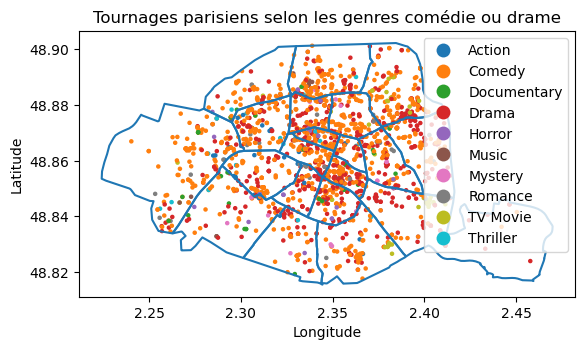

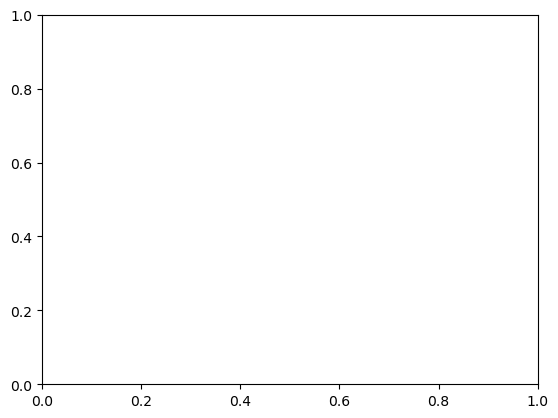

In [24]:
#afficher un fond de carte représentant les arrondissements parisiens
base = arrondissement_borders.boundary.plot()

#créer un nuage de points colorié en fonction du "genre"
fig, ax = plt.subplots()
ax=base
filtred_gdf_merge.plot(
    ax=ax,
    column='main_genre_name', #colonne pour colorier les points
    categorical=True, #couleurs distinctes
    legend=True,
    markersize=5,
)

ax.set_title('Tournages parisiens selon les genres comédie ou drame')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()


Pour chaque arrondissement, on va chercher à afficher sur la carte le poids du genre majoritaire parmi les autres genres.

In [25]:
#calcul des effectifs par arrondissement
count_total= filtred_gdf_merge.groupby('Code postal').size() #total
count_drama = filtred_gdf_merge.groupby('Code postal')['main_genre_name'].apply(lambda col: (col == 'Drama').sum()) #drame
count_comedy = filtred_gdf_merge.groupby('Code postal')['main_genre_name'].apply(lambda col: (col == 'Comedy').sum()) #comedy

#conversion en dataframe
df_count_total = count_total.to_frame()
df_count_drama = count_drama.to_frame()
df_count_comedy= count_comedy.to_frame()

print('nombre de tournage par arrondissement :')
print(df_count_total.head(3))
print('nombre de drames par arrondissement :')
print(df_count_drama.head(3))
print('nombre de comédies par arrondissement :')
print(df_count_comedy.head(3))



nombre de tournage par arrondissement :
              0
Code postal    
75001.0      82
75002.0      69
75003.0      27
nombre de drames par arrondissement :
             main_genre_name
Code postal                 
75001.0                   30
75002.0                   21
75003.0                   10
nombre de comédies par arrondissement :
             main_genre_name
Code postal                 
75001.0                   43
75002.0                   36
75003.0                   13


In [26]:
#construction des annotations pour la carte
annotations=[]
drama_majoritaire=[]

for code_postal in filtred_gdf_merge['Code postal'].unique():
    #calcul du pourcentage du poids du genre majoritaire parmi les autres genres
    pourcentage=max(df_count_drama['main_genre_name'].loc[code_postal], df_count_comedy['main_genre_name'].loc[code_postal])/df_count_total[0].loc[code_postal]*100
    pourcentage_affiche = f"{pourcentage:.1f}%"

    #les annotations contiennent les coordonnées et le pourcentage à afficher pour chaque arrondissement
    annotations = annotations + [[df_mean_x['Coordonnée en X'].loc[code_postal],df_mean_y['Coordonnée en Y'].loc[code_postal],pourcentage_affiche]]

    #créer une liste de boolean qui indique pour chaque arrondissement si les drames sont majoritaires par rapport aux comédies
    drama_majoritaire = drama_majoritaire + [df_count_drama['main_genre_name'].loc[code_postal]>=df_count_comedy['main_genre_name'].loc[code_postal]]

print(drama_majoritaire)
print('les coordonnées et le pourcentage pour le 1er arrondissement sont respectivement '+ str(annotations[0]))

[np.True_, np.False_, np.False_, np.True_, np.False_, np.False_, np.False_, np.False_, np.False_, np.True_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_, np.False_]
les coordonnées et le pourcentage pour le 1er arrondissement sont respectivement [np.float64(2.39660629010101), np.float64(48.84201954434343), '46.9%']


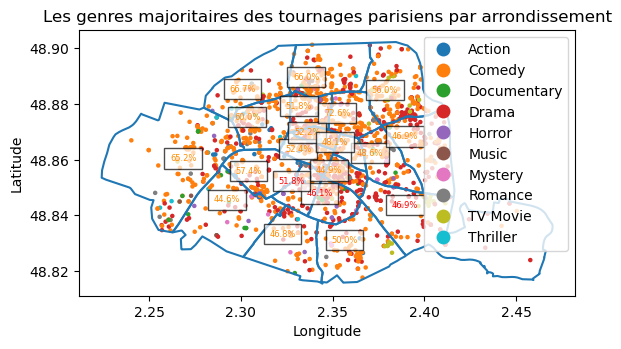

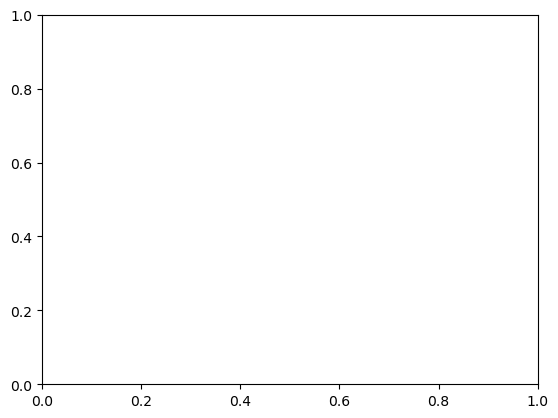

In [ ]:
O
#ajout des annoations
for x, y, etiquette in annotations:

    ax.text(
        x, y, etiquette, 
        fontsize=6, color=c[int(drama_majoritaire[i])], 
        ha='right', va='bottom',  # Alignement horizontal et vertical
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='k')  # Fond du texte
    )
    i=i+1
    

ax.set_title('Les genres majoritaires des tournages parisiens par arrondissement')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

Ces résultats découlent directement de la prédominance des comédies par rapport aux drames dans la base de données mergée. On voit néanmoins que les drames sont plus nombreux que les comédies pour les arrondissements 5, 6 et 12, où il y a respectivement 46.1 %, 51.8 % et 46.9 % de drame parmi les lieux de tournage. L'objectif va être maintenant d'obtenir des ratios comparables en pondérant les effectifs de comédies ou de drames dans chaque arrondissement par les effectifs totaux de comédies ou de drames dans le jeu de données.

In [35]:
#compter les effectifs totaux pour les genres comédie et drame
effectif_total_comedy=df_count_genre.loc['Comedy',0]
effectif_total_drama=df_count_genre.loc['Drama',0]

print('le nombre de comédies dans la base de données mergée est : ' + str(effectif_total_comedy))
print('le nombre de drames dans la base de données mergée est : ' + str(effectif_total_drama))

le nombre de comédies dans la base de données mergée est : 994
le nombre de drames dans la base de données mergée est : 606


In [39]:
#construction des annotations pour la carte
annotations=[]
drama_majoritaire=[]

for code_postal in filtred_gdf_merge['Code postal'].unique():
    #calcul du pourcentage du poids du genre majoritaire parmi les autres genres
    pourcentage=max(df_count_drama['main_genre_name'].loc[code_postal]/effectif_total_drama, df_count_comedy['main_genre_name'].loc[code_postal]/effectif_total_comedy)*100
    pourcentage_affiche = f"{pourcentage:.1f}%"

    #les annotations contiennent les coordonnées et le pourcentage à afficher pour chaque arrondissement
    annotations = annotations + [[df_mean_x['Coordonnée en X'].loc[code_postal],df_mean_y['Coordonnée en Y'].loc[code_postal],pourcentage_affiche]]

    #créer une liste de boolean qui indique pour chaque arrondissement si les drames sont majoritaires par rapport aux comédies
    drama_majoritaire = drama_majoritaire + [df_count_drama['main_genre_name'].loc[code_postal]/effectif_total_drama>=df_count_comedy['main_genre_name'].loc[code_postal]/effectif_total_comedy]

print(drama_majoritaire)
print('les coordonnées et le pourcentage pour le 1er arrondissement sont respectivement '+ str(annotations[0]))

[np.True_, np.True_, np.False_, np.True_, np.True_, np.False_, np.True_, np.False_, np.True_, np.True_, np.True_, np.False_, np.False_, np.False_, np.False_, np.True_, np.True_, np.True_, np.False_, np.True_]
les coordonnées et le pourcentage pour le 1er arrondissement sont respectivement [np.float64(2.39660629010101), np.float64(48.84201954434343), '7.4%']


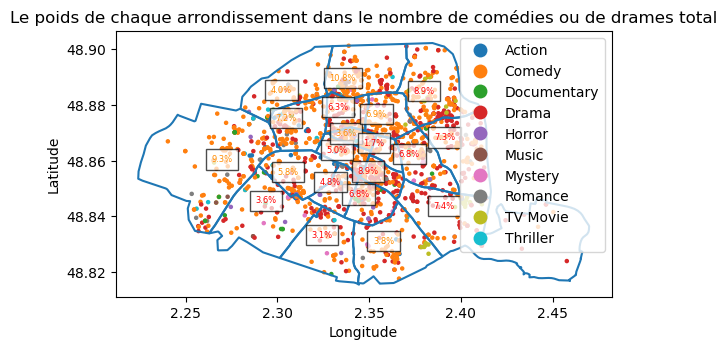

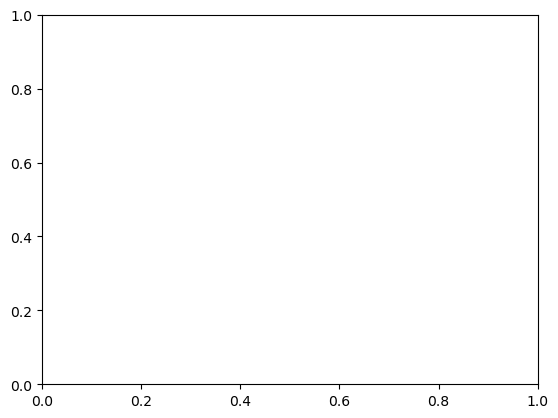

In [43]:
base = arrondissement_borders.boundary.plot()

#créer un nuage de points colorié en fonction du "genre"
fig, ax = plt.subplots()
ax=base
filtred_gdf_merge.plot(
    ax=ax,
    column='main_genre_name', #colonne pour colorier les points
    categorical=True, #couleurs distinctes
    legend=True,
    markersize=5,
)

#vecteur des couleurs des points 
c=['darkorange','red']

i=0
#ajout des annoations
for x, y, etiquette in annotations:

    ax.text(
        x, y, etiquette, 
        fontsize=6, color=c[int(drama_majoritaire[i])], 
        ha='right', va='bottom',  # Alignement horizontal et vertical
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='k')  # Fond du texte
    )
    i=i+1
    

ax.set_title('Le poids de chaque arrondissement dans le nombre de comédies ou de drames total')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

Cette représentation cartographique permet de mettre en lumière quels arrondissements contribuent le moins au nombre de comédies et de drames : ce sont les arrondissements dans le sud de Paris. Ils représentent au maximum environ 3 % des comédies ou les drames. 
La répartition des arrondissements qui contribuent le plus aux genres comedie et drame est plus ou moins uniforme.